In [1]:
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/CONTACT/STIS/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Load files

In [4]:
fits_ref = fits.open(rootdir+'PG1522+101_E230M_new.fits')

Load FITS files for all exposures

In [5]:
exp_names = ['of8g05010', 'of8g05020', 'of8g05030', 'of8g08010', 'of8g08020']
fits_list = [fits.open(rootdir+'J011035/unstitched_es=4/{}_x1d.fits'.format(e))[1] for e in exp_names]

Define grid parameters

In [6]:
# Save grid shape
n_exps = len(exp_names)
n_orders = fits_list[0].data['wavelength'].shape[0]
n_pixels = fits_list[0].data['wavelength'].shape[1]

# Stitching

## V1: using fluxes

Save spectroscopic data (wavelengths, fluxes, errors) across all exposures and orders

In [7]:
# From all exposures, all orders, all pixels, load in wavelengths, fluxes, and errors
spec_data = np.zeros((n_exps, n_orders, n_pixels, 3))

for i in range(n_exps):
    for j in range(n_orders):
        # Load orders in reverse because that means increasing wavelengths
        spec_data[i,j,:,0] = fits_list[i].data[n_orders-j-1]['wavelength']
        spec_data[i,j,:,1] = fits_list[i].data[n_orders-j-1]['flux']
        spec_data[i,j,:,2] = fits_list[i].data[n_orders-j-1]['error']

Create a wavelength grid to be used uniformly for stacking, making sure that wavelengths for overlapping orders are the same

In [8]:
# Some orders have overlapping wavelengths, so take care of that by modifying the wavelength grid
wav_order_grid = np.zeros((n_orders, n_pixels))
# Lowest wavelength order is fine, keep as is
wav_order_grid[0,:] = spec_data[0,0,:,0]

# For each subsequent order
for i in range(n_orders-1):

    # Wavelengths of order 1
    wav_order_1 = spec_data[0,i,:,0]
    # Wavelengths of order 2
    wav_order_2 = spec_data[0,i+1,:,0]

    # Compute differences of order 1 wavelengths from the 0th element of order 2
    del_wav_arr = wav_order_1-wav_order_2[0]

    # This operation gives the index of the element of order 1 whose wavelength is right before the 0th element of order 2
    idx = list(del_wav_arr).index(max(del_wav_arr[del_wav_arr<0]))

    # Number of pixels in first order that are offset from the second order
    n_rem_order_1 = len(wav_order_1[idx:])
    # Copy over wavelengths to the second order
    wav_order_2[0:n_rem_order_1] = wav_order_1[idx:].copy()

    # Save the modified second order in the wavelength grid
    wav_order_grid[i+1,:] = wav_order_2.copy()

Interpolate the fluxes and errors for various exposures and orders

In [9]:
# Interpolate fluxes over the rectified wavelength grid
spec_data_interp = spec_data.copy()

for i in range(n_exps):
    for j in range(n_orders):

        # The shifted wavelength grid for an order
        wav_order = wav_order_grid[j,:]

        # Original grid
        wav_order_og = spec_data[i,j,:,0]
        flux_order_og = spec_data[i,j,:,1]
        var_order_og = spec_data[i,j,:,2]**2

        # Interpolate flux and variance
        flux_order = np.interp(wav_order, wav_order_og, flux_order_og)
        var_order = np.interp(wav_order, wav_order_og, var_order_og)

        # Store in the new full grid
        spec_data_interp[i,j,:,0] = wav_order
        spec_data_interp[i,j,:,1] = flux_order
        spec_data_interp[i,j,:,2] = np.sqrt(var_order)

Before stitching, check variance among different exposures

In [10]:
flux_ref = spec_data_interp[0,:,:,1]
err_rev = spec_data_interp[0,:,:,2]

In [11]:
df_sig = np.zeros((n_exps-1, n_orders, n_pixels))

for i in range(1,n_exps):
    flux = spec_data_interp[i,:,:,1]
    err = spec_data_interp[i,:,:,2]
    
    df_sig[i-1,:,:] = (flux-flux_ref)/np.sqrt(err_rev**2 + err**2)

Text(0, 0.5, 'Counts')

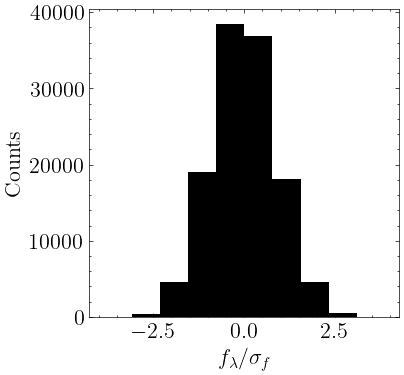

In [12]:
fig, ax = plt.subplots(1, figsize=(4,4))
ax.hist(df_sig.flatten())
ax.set_xlabel(r'$f_\lambda/\sigma_f$')
ax.set_ylabel('Counts')

Alignment seems fine, stitch everything together. First, make a wave dictionary to map fluxes and errors to unique wavelengths

In [13]:
wav_stitch = np.unique(wav_order_grid)

In [14]:
# Map fluxes and errors for each wavelength across all exposures
wav_dict = {w:[] for w in wav_stitch}

for i in range(n_exps):
    for j in range(n_orders):
        wav_order = spec_data_interp[i,j,:,0]
        
        for k in range(n_pixels):

            w = spec_data_interp[i,j,k,0]
            f = spec_data_interp[i,j,k,1]
            s = spec_data_interp[i,j,k,2]
    
            # Trim edges of each order
            if wav_order[0]+2<w<wav_order[-1]-5:
                wav_dict[w].append([f,s])    

Now, co-add fluxes. First reject negative fluxes, then do median clipping. Finally, add fluxes with inverse variance weighting.

In [15]:
SN_thresh = -3
sig_thresh = 3

In [16]:
# Store co-added fluxes and errors
flux_stitch_v1 = np.zeros(len(wav_stitch))
err_stitch_v1 = np.zeros(len(wav_stitch))

# Also keep track of fraction of rejected measurements from S/N threshold and sigma-clipping 
reject_stitch_1 = np.zeros(len(wav_stitch))
reject_stitch_2 = np.zeros(len(wav_stitch))

for i in range(len(wav_stitch)):

    # Get wavelength, and quantities (flux, error) to be combined
    w = wav_stitch[i]
    spec_arr = np.array(wav_dict[w])
    
    if len(spec_arr)!=0:
        flux_arr = spec_arr[:,0]
        err_arr = spec_arr[:,1]

        # Number of measurements, from multiple exposures and overlapping orders
        obs_count = len(flux_arr)

        # Reject fluxes that are "too" negative, record fraction of rejections
        idx_1 = flux_arr/err_arr < SN_thresh
        reject_stitch_1[i] = np.sum(idx_1)/obs_count

        # Fluxes and errors after rejecting
        flux_arr = flux_arr[~idx_1]
        err_arr = err_arr[~idx_1]

        # Next, after rejecting these points, perform median filtering
        mu = np.median(flux_arr)
        sigma = np.sqrt(np.mean((flux_arr-mu)**2))

        # Reject points, record number of rejections
        idx_2 = np.abs(flux_arr-mu)>sig_thresh*sigma
        reject_stitch_2[i] = np.sum(idx_2)/obs_count

        # Fluxes and errors that are good to go
        flux_arr = flux_arr[~idx_2]
        err_arr = err_arr[~idx_2]  

        # Decide weights for each measurement, inverse varance weighting
        # This minimizes the variance
        wts_arr = 1/err_arr**2
        # Ensure weights are normalized to one
        wts_arr /= np.sum(wts_arr)

        # Record the co-added fluxes and errors
        flux_stitch_v1[i] = np.sum(wts_arr*flux_arr)
        # Apply square of weights to variance, then add, then 
        err_stitch_v1[i] = np.sqrt(np.sum(wts_arr**2*err_arr**2))

Plot the stitched spectrum

Text(0, 0.5, 'Flux (erg/s/cm${}^2$/Å)')

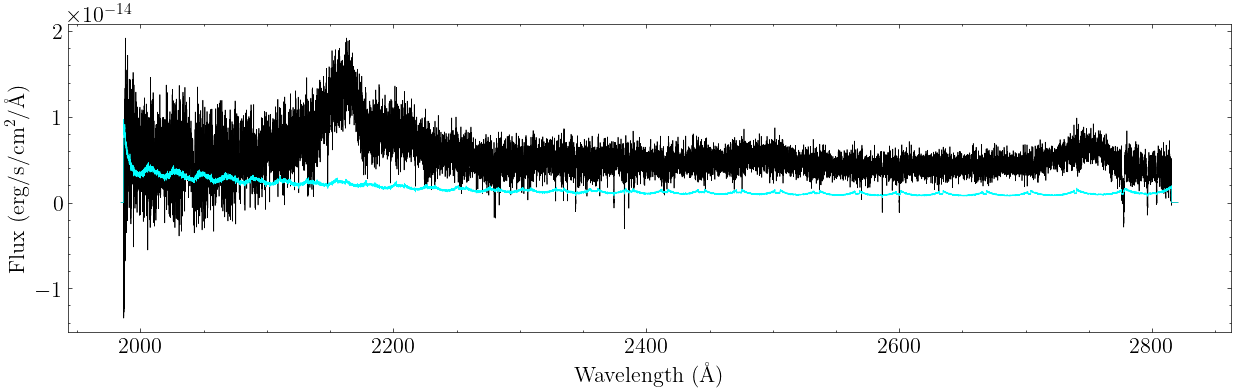

In [17]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.step(wav_stitch, flux_stitch_v1, where='mid', color='black', lw=.5)
ax.step(wav_stitch, err_stitch_v1, where='mid', color='cyan', lw=.5)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

Assess S/N

In [18]:
idx_1 = wav_stitch>2150
idx_2 = wav_stitch>2300

SN_1_v1 = flux_stitch_v1[idx_1]/err_stitch_v1[idx_1]
SN_2_v1 = flux_stitch_v1[idx_2]/err_stitch_v1[idx_2]

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_4354/3415465441.py:4: RuntimeWarning: invalid value encountered in divide
  SN_1_v1 = flux_stitch_v1[idx_1]/err_stitch_v1[idx_1]
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_4354/3415465441.py:5: RuntimeWarning: invalid value encountered in divide
  SN_2_v1 = flux_stitch_v1[idx_2]/err_stitch_v1[idx_2]


Text(0, 0.5, 'Counts')

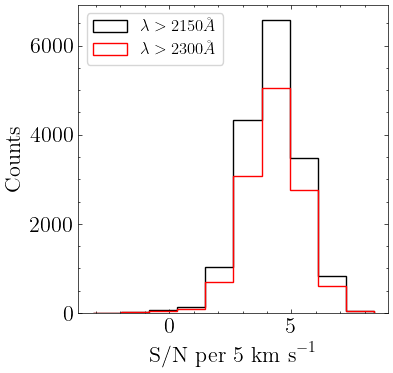

In [19]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(SN_1_v1, histtype='step', color='black', label=r'$\lambda > 2150 Å$')
ax.hist(SN_2_v1, histtype='step', color='red', label=r'$\lambda > 2300 Å$')

ax.legend(loc='upper left')

ax.set_xlabel(r'S/N per 5 $\mathrm{km \ s}^{-1}$')
ax.set_ylabel('Counts')

In [20]:
np.nanmedian(SN_1_v1), np.nanmedian(SN_2_v1)

(4.230084128706117, 4.287783412242273)

In [21]:
# Define data columns
c1 = fits.Column(name='wave    ', array=wav_stitch, format='D')
c2 = fits.Column(name='flux    ', array=flux_stitch_v1, format='D')
c3 = fits.Column(name='error   ', array=err_stitch_v1, format='D')

# Make HDU table
table_hdu = fits.BinTableHDU.from_columns([c1, c2, c3])

# Make HDU
hdu = fits.HDUList([fits_ref[0], table_hdu])  

# Check if path exists, otherwise make it
#Path(savedir).mkdir(parents=True, exist_ok=True)
# Write HDU
hdu.writeto(rootdir + 'J011035/J011035_SK_flux_coadd.fits', overwrite=True)

## V2: using counts

Get list of exposure times

In [22]:
exp_times = [f.header['exptime'] for f in fits_list]

Make a grid for wavelengths, gross counts, background counts, data quality, flux 

In [23]:
# From all exposures, all orders, all pixels, load in wavelengths, gross counts, background counts, exposure times, data quality flags, and flux
spec_data = np.zeros((n_exps, n_orders, n_pixels, 6))

for i in range(n_exps):
    for j in range(n_orders):
        # Load orders in reverse because that means increasing wavelengths
        spec_data[i,j,:,0] = fits_list[i].data[n_orders-j-1]['wavelength']
        spec_data[i,j,:,1] = fits_list[i].data[n_orders-j-1]['gross']*exp_times[i] # Convert to counts
        spec_data[i,j,:,2] = fits_list[i].data[n_orders-j-1]['background']*exp_times[i] # To give net counts
        spec_data[i,j,:,3] = exp_times[i] # For weighting multiple exposures
        spec_data[i,j,:,4] = fits_list[i].data[n_orders-j-1]['dq']
        spec_data[i,j,:,5] = fits_list[i].data[n_orders-j-1]['flux'] # For flux calibration later

In [24]:
np.sum(spec_data[:,:,:,4].flatten()==0), np.sum(spec_data[:,:,:,4].flatten()!=0)

(144904, 8696)

Plot counts to check if small number statistics apply

Text(0, 0.5, 'Frequency Counts')

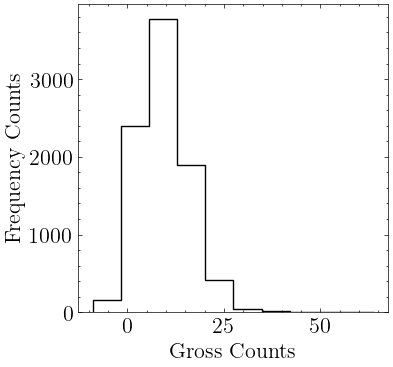

In [25]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(spec_data[:,:,:,1].flatten()[spec_data[:,:,:,4].flatten()!=0], histtype='step')

ax.set_xlabel('Gross Counts')
ax.set_ylabel('Frequency Counts')

Small number statistics do apply for a non-negligible portion of measurements. Anyways, go ahead and create a wavelength grid to take care of overlapping orders.

In [26]:
# Some orders have overlapping wavelengths, so take care of that by modifying the wavelength grid
wav_order_grid = np.zeros((n_orders, n_pixels))
# Lowest wavelength order is fine, keep as is
wav_order_grid[0,:] = spec_data[0,0,:,0]

# For each subsequent order
for i in range(n_orders-1):

    # Wavelengths of order 1
    wav_order_1 = spec_data[0,i,:,0]
    # Wavelengths of order 2
    wav_order_2 = spec_data[0,i+1,:,0]

    # Compute differences of order 1 wavelengths from the 0th element of order 2
    del_wav_arr = wav_order_1-wav_order_2[0]

    # This operation gives the index of the element of order 1 whose wavelength is right before the 0th element of order 2
    idx = list(del_wav_arr).index(max(del_wav_arr[del_wav_arr<0]))

    # Number of pixels in first order that are offset from the second order
    n_rem_order_1 = len(wav_order_1[idx:])
    # Copy over wavelengths to the second order
    wav_order_2[0:n_rem_order_1] = wav_order_1[idx:].copy()

    # Save the modified second order in the wavelength grid
    wav_order_grid[i+1,:] = wav_order_2.copy()

Interpolate counts to the new wavelength array

In [27]:
# Interpolate fluxes over the rectified wavelength grid
spec_data_interp = spec_data.copy()

for i in range(n_exps):
    for j in range(n_orders):

        # The shifted wavelength grid for an order
        wav_order = wav_order_grid[j,:]

        # Original grid
        wav_order_og = spec_data[i,j,:,0]
        gross_order_og = spec_data[i,j,:,1]
        bg_order_og = spec_data[i,j,:,2]
        flux_order_og = spec_data[i,j,:,5]

        # Interpolate flux and variance
        gross_order = np.interp(wav_order, wav_order_og, gross_order_og)
        bg_order = np.interp(wav_order, wav_order_og, bg_order_og)
        flux_order = np.interp(wav_order, wav_order_og, flux_order_og)

        # Store in the new full grid
        spec_data_interp[i,j,:,0] = wav_order
        spec_data_interp[i,j,:,1] = gross_order
        spec_data_interp[i,j,:,2] = bg_order
        spec_data_interp[i,j,:,5] = flux_order

Create a wave dictionary to map observables to unique wavelengths

In [28]:
wav_stitch = np.unique(wav_order_grid)

In [29]:
# Map fluxes and errors for each wavelength across all exposures
wav_dict = {w:[] for w in wav_stitch}

for i in range(n_exps):
    for j in range(n_orders):
    
        wav_order = spec_data_interp[i,j,:,0]

        for k in range(n_pixels):

            w = spec_data_interp[i,j,k,0] # Wavelength
            g = spec_data_interp[i,j,k,1] # Gross
            bg = spec_data_interp[i,j,k,2] # Background
            et = spec_data_interp[i,j,k,3] # Exposure time
            dq = spec_data_interp[i,j,k,4] # Data quality
            f = spec_data_interp[i,j,k,5] # Flux
            
            # Trim edges of each order
            if wav_order[0]+2<w<wav_order[-1]-5:            
                wav_dict[w].append([g,bg,et,dq,f])    

Since co-adding requires inverse variance weighting and we might be dealing with low counts, first implement Poisson counting confidence intervals.

In [31]:
import scipy.optimize as opt
import scipy.stats as st

In [32]:
# Poisson distribution
def poisson(n, lam):
    
    return lam**n*np.exp(-lam)/np.math.factorial(n)

# Equation for upper bound
def lam_u_eqn(lam_u, n, C):
    
    # Generate array of x values
    x_arr = np.arange(0,n+1)
    
    poisson_x = np.array([poisson(x, lam_u) for x in x_arr])
    
    return np.sum(poisson_x)-(1-C)

# Equation for lower bound
def lam_l_eqn(lam_l, n, C):
    
    # Generate array of x values
    x_arr = np.arange(0,n)
    
    poisson_x = np.array([poisson(x, lam_l) for x in x_arr])
    
    return np.sum(poisson_x)-C

# Approximate solutions for seeding
def lam_u_approx(n, C):
    
    # First compute number of Gaussian sigma
    S = st.norm.ppf(C)
    
    # Now use the formula
    return n + S*np.sqrt(n+1) + ((S**2+2)/3)

def lam_l_approx(n, C):
    
    if(n==0):
        return 0
    
    # First compute number of Gaussian sigma
    S = st.norm.ppf(C)
    
    # Now use the formula
    return n - S*np.sqrt(n) + ((S**2-1)/3)

# Solve upper bound
def lam_u_eqn_solve(n, C):
    
    lam_u = opt.fsolve(lam_u_eqn, x0=lam_u_approx(n, C), args=(n, C))[0]
        
    return lam_u

# Solve lower bound
def lam_l_eqn_solve(n, C):
    
    if(n==0):
        return 0
    
    lam_l = opt.fsolve(lam_l_eqn, x0=lam_l_approx(n, C), args=(n, C))[0]
    
    return lam_l

In [33]:
n_arr = np.arange(0, 70)
lam_u_exact_arr = np.array([lam_u_eqn_solve(n, 0.8413) for n in n_arr])
lam_l_exact_arr = np.array([lam_l_eqn_solve(n, 0.8413) for n in n_arr])

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_4354/22264841.py:4: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return lam**n*np.exp(-lam)/np.math.factorial(n)


(0.0, 20.0)

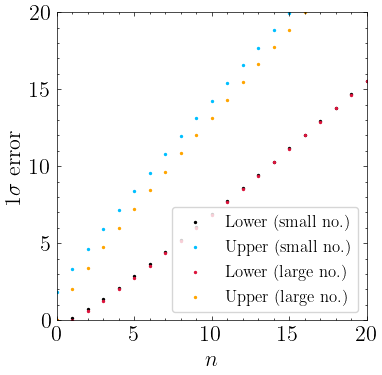

In [34]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.scatter(n_arr, lam_l_exact_arr, label='Lower (small no.)', s=2)
ax.scatter(n_arr, lam_u_exact_arr, label='Upper (small no.)', s=2)
ax.scatter(n_arr, n_arr-np.sqrt(n_arr), label='Lower (large no.)', s=2)
ax.scatter(n_arr, n_arr+np.sqrt(n_arr), label='Upper (large no.)', s=2)

ax.legend()

ax.set_xlabel(r'$n$')
ax.set_ylabel(r'$1\sigma$ error')

ax.set_xlim(0,20)
ax.set_ylim(0,20)

Counts are technically supposed to be integers, but in this case sometimes they might not be. So let us interpolate the errors across integers.

In [35]:
from scipy.interpolate import interp1d

In [36]:
lam_l_interp = interp1d(n_arr, lam_l_exact_arr, fill_value='extrapolate')
lam_u_interp = interp1d(n_arr, lam_u_exact_arr, fill_value='extrapolate')

In [37]:
lam_l_exact_arr[4], lam_l_exact_arr[5]

(2.0858990146776475, 2.8405913496225943)

In [38]:
lam_l_interp(4), lam_l_interp(5), lam_l_interp(4.5)

(array(2.08589901), array(2.84059135), array(2.46324518))

Add up counts; reject bad data quality points

In [39]:
# Store co-added gross and net count rates
gross_cts_stitch = np.zeros(len(wav_stitch))
bg_cts_stitch = np.zeros(len(wav_stitch))
err_cts_stitch = np.zeros(len(wav_stitch))
exp_time_stitch = np.zeros(len(wav_stitch))

# For flux calibration later
net_ct_rate_dict = {}
flux_dict = {}

for i in range(len(wav_stitch)):

    # Get wavelength, and quantities (flux, error) to be combined
    w = wav_stitch[i]
    spec_arr = np.array(wav_dict[w])
    
    if len(spec_arr)!=0:
        gross_arr = spec_arr[:,0]
        bg_arr = spec_arr[:,1]
        et_arr = spec_arr[:,2]
        dq_arr = spec_arr[:,3]
        flux_arr = spec_arr[:,4]

        # Reject counts that have bad data quality
        idx = (dq_arr!=0)

        # Counts and exposure times after rejecting
        gross_arr = gross_arr[~idx]
        bg_arr = bg_arr[~idx]
        et_arr = et_arr[~idx]
        dq_arr = dq_arr[~idx]
        flux_arr = flux_arr[~idx]

        # Save net count rate and fluxes first
        net_ct_rate_dict[w] = (gross_arr-bg_arr)/et_arr
        flux_dict[w] = flux_arr

        # Record the co-added fluxes and errors
        gross_counts = np.sum(gross_arr)
        # Obtain errors using gross counts
        err_lo = gross_counts-lam_l_interp(gross_counts)
        err_hi = lam_u_interp(gross_counts)-gross_counts
        err = .5*(err_lo + err_hi) # Take the average    

        gross_cts_stitch[i] = gross_counts
        bg_cts_stitch[i] = np.sum(bg_arr)
        err_cts_stitch[i] = err
        exp_time_stitch[i] = np.sum(et_arr)

(-5.0, 120.0)

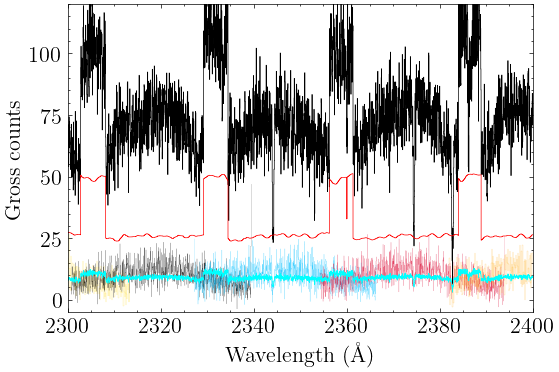

In [40]:
fig, ax = plt.subplots(1, figsize=(6,4))

for j in range(n_orders):
    ax.step(fits_list[0].data[n_orders-j-1]['wavelength'], 
            fits_list[0].data[n_orders-j-1]['gross']*exp_times[0], where='mid', lw=.1)

ax.step(wav_stitch, gross_cts_stitch, where='mid', color='black', lw=.5)
ax.step(wav_stitch, bg_cts_stitch, where='mid', color='red', lw=.5)

ax.step(wav_stitch, err_cts_stitch, where='mid', color='cyan', lw=.5)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Gross counts')

ax.set_xlim(2300,2400)
ax.set_ylim(-5,120)
#ax.set_ylim(-0.005, 0.015)

(-5.0, 100.0)

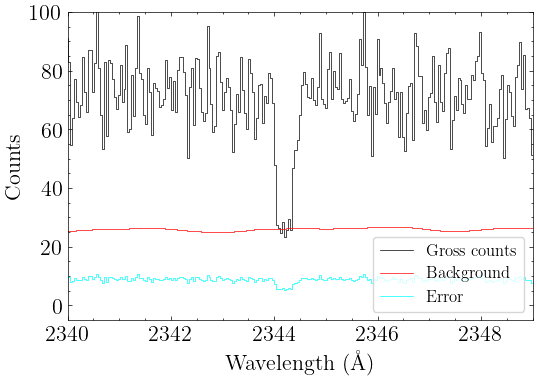

In [44]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.step(wav_stitch, gross_cts_stitch, where='mid', color='black', lw=.5, label='Gross counts')
ax.step(wav_stitch, bg_cts_stitch, where='mid', color='red', lw=.5, label='Background')

ax.step(wav_stitch, err_cts_stitch, where='mid', color='cyan', lw=.5, label='Error')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Counts')

ax.legend(loc='lower right')

ax.set_xlim(2340,2349)
ax.set_ylim(-5,100)

#ax.set_ylim(-0.001, 0.007)

For flux calibration, count rates are necessary

In [45]:
net_ct_rates_stitch = (gross_cts_stitch-bg_cts_stitch)/exp_time_stitch
err_ct_rates_stitch = err_cts_stitch/exp_time_stitch

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_4354/873220170.py:1: RuntimeWarning: invalid value encountered in divide
  net_ct_rates_stitch = (gross_cts_stitch-bg_cts_stitch)/exp_time_stitch
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_4354/873220170.py:2: RuntimeWarning: divide by zero encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_4354/873220170.py:2: RuntimeWarning: invalid value encountered in divide
  err_ct_rates_stitch = err_cts_stitch/exp_time_stitch


(-0.005, 0.015)

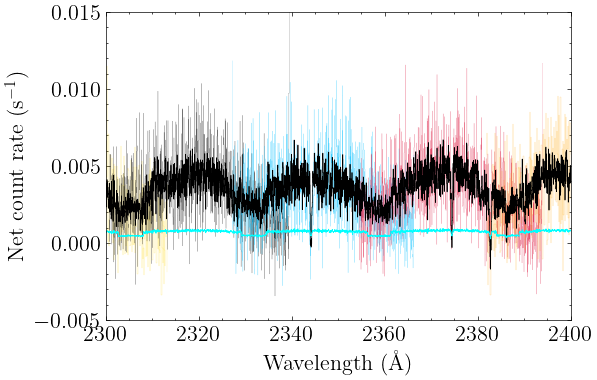

In [46]:
fig, ax = plt.subplots(1, figsize=(6,4))

for j in range(n_orders):
    ax.step(fits_list[0].data[n_orders-j-1]['wavelength'], 
            fits_list[0].data[n_orders-j-1]['net'], where='mid', lw=.1)

ax.step(wav_stitch, net_ct_rates_stitch, where='mid', color='black', lw=.5)

ax.step(wav_stitch, err_ct_rates_stitch, where='mid', color='cyan', lw=.5)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Net count rate ($\mathrm{s}^{-1}$)')

ax.set_xlim(2300,2400)
#ax.set_ylim(-5,120)
ax.set_ylim(-0.005, 0.015)

(-0.001, 0.007)

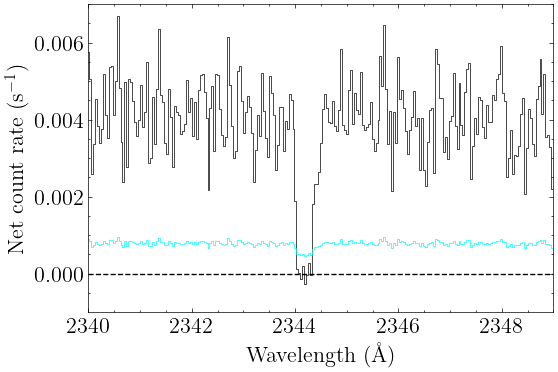

In [49]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.step(wav_stitch, net_ct_rates_stitch, where='mid', color='black', lw=.5)

ax.step(wav_stitch, err_ct_rates_stitch, where='mid', color='cyan', lw=.5)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Net count rate ($\mathrm{s}^{-1}$)')
ax.axhline(0, linestyle='--')

ax.set_xlim(2340,2349)
#ax.set_ylim(-5,120)
ax.set_ylim(-0.0025, 0.008)
ax.set_ylim(-0.001, 0.007)

In [44]:
f = net_ct_rates_stitch[(wav_stitch>2340)&(wav_stitch<2343)]
s = err_ct_rates_stitch[(wav_stitch>2340)&(wav_stitch<2343)]

In [45]:
np.mean(f/s)

5.23050541534191

Now form the sensitivity function

In [46]:
# Plot points
wav_flat = []
sens_flat = []
for w in wav_stitch:
    
    if w in list(flux_dict.keys()):
        for i in range(len(flux_dict[w])):
            wav_flat.append(w)
            sens_flat.append(flux_dict[w][i]/net_ct_rate_dict[w][i])
    else:
        wav_flat.append(w)
        sens_flat.append(np.nan)

In [47]:
# Median relation
sens_med = np.zeros(len(wav_stitch))

for i in range(len(wav_stitch)):
    w = wav_stitch[i]
    if w in list(flux_dict.keys()):
        sens_med[i] = np.median(flux_dict[w]/net_ct_rate_dict[w])
    else:
        sens_med[i] = 0

/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [48]:
# Smooth out

win_size = 1.5 # Å

sens_smooth = np.zeros(len(wav_stitch))

for i in range(len(wav_stitch)):
    
    w = wav_stitch[i]
    idx = (wav_stitch>=w-win_size/2)&(wav_stitch<w+win_size/2)
    
    sens_smooth[i] = np.median(sens_med[idx])

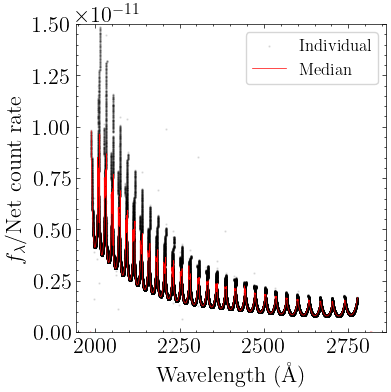

In [49]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.scatter(wav_flat, sens_flat, s=.5, alpha=.1, label='Individual')
ax.plot(wav_stitch, sens_med, lw=.5, color='red', label='Median')
#ax.plot(wav_stitch, sens_smooth, lw=1, color='cyan')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'$f_\mathrm{\lambda}/\mathrm{Net \ count \ rate}$')
ax.set_ylim(0,1.5e-11)

ax.legend()

(0.0, 1.5e-11)

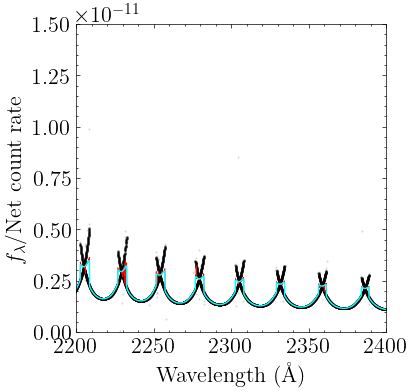

In [50]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.scatter(wav_flat, sens_flat, s=.5, alpha=.1)
ax.plot(wav_stitch, sens_med, lw=.5, color='red')
ax.plot(wav_stitch, sens_smooth, lw=1, color='cyan')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'$f_\mathrm{\lambda}/\mathrm{Net \ count \ rate}$')
ax.set_xlim(2200,2400)
ax.set_ylim(0,1.5e-11)


In [51]:
flux_stitch_v2 = net_ct_rates_stitch*sens_med
err_stitch_v2 = err_ct_rates_stitch*sens_med

(0.0, 1e-14)

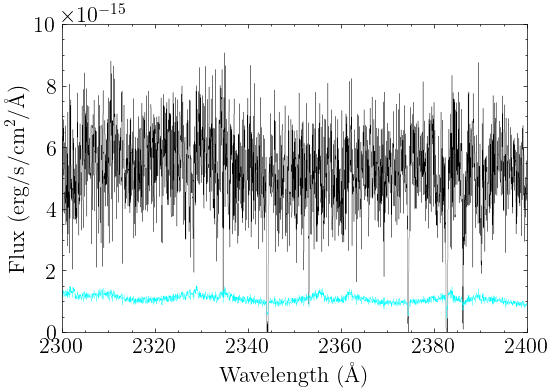

In [52]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.step(wav_stitch, flux_stitch_v2, where='mid', color='black', lw=.2)
ax.step(wav_stitch, err_stitch_v2, where='mid', color='cyan', lw=.2)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

ax.set_xlim(2300,2400)
ax.set_ylim(0, 1.e-14)
#ax.set_ylim(-0.005, 0.015)

(-2e-15, 1e-14)

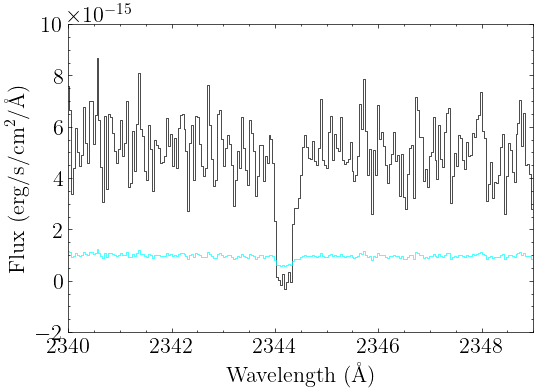

In [53]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.step(wav_stitch, flux_stitch_v2, where='mid', color='black', lw=.5)
ax.step(wav_stitch, err_stitch_v2, where='mid', color='cyan', lw=.5)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

ax.set_xlim(2340,2349)
ax.set_ylim(-2e-15, 1e-14)

In [54]:
SN_1_v2 = flux_stitch_v2[wav_stitch>2150]/err_stitch_v2[wav_stitch>2150]
SN_2_v2 = flux_stitch_v2[wav_stitch>2300]/err_stitch_v2[wav_stitch>2300]

Text(0, 0.5, 'Counts')

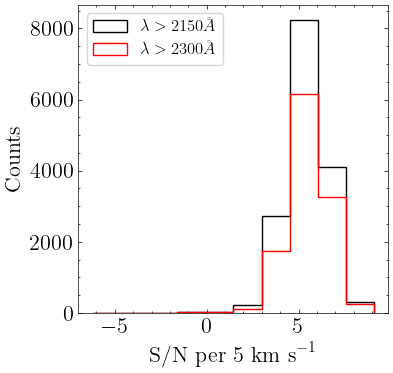

In [55]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(SN_1_v2, histtype='step', color='black', label=r'$\lambda > 2150 Å$')
ax.hist(SN_2_v2, histtype='step', color='red', label=r'$\lambda > 2300 Å$')

ax.legend(loc='upper left')

ax.set_xlabel(r'S/N per 5 $\mathrm{km \ s}^{-1}$')
ax.set_ylabel('Counts')

In [56]:
np.nanmedian(SN_1_v2), np.nanmedian(SN_2_v2)

(5.464298100054304, 5.5614911760012795)

In [57]:
# Define data columns
c1 = fits.Column(name='wave    ', array=wav_stitch, format='D')
c2 = fits.Column(name='flux    ', array=flux_stitch_v2, format='D')
c3 = fits.Column(name='error   ', array=err_stitch_v2, format='D')

# Make HDU table
table_hdu = fits.BinTableHDU.from_columns([c1, c2, c3])

# Make HDU
hdu = fits.HDUList([fits_ref[0], table_hdu])  

# Check if path exists, otherwise make it
#Path(savedir).mkdir(parents=True, exist_ok=True)
# Write HDU
hdu.writeto(rootdir + 'J011035/J011035_SK_count_coadd.fits', overwrite=True)

## Comparison between V1 and V2

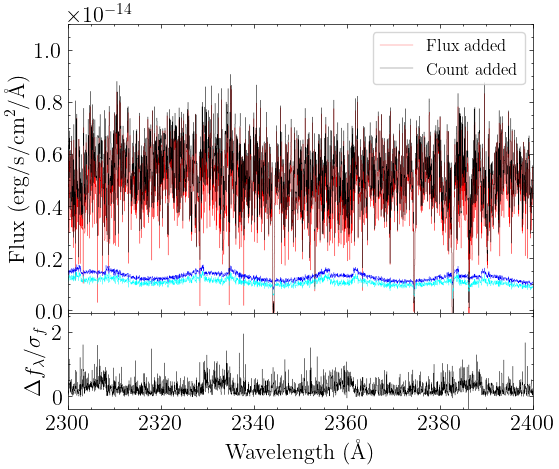

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(6,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(wav_stitch, flux_stitch_v1, where='mid', color='red', lw=.2, label='Flux added')
axes[0].step(wav_stitch, err_stitch_v1, where='mid', color='blue', lw=.2)

axes[0].step(wav_stitch, flux_stitch_v2, where='mid', color='black', lw=.2, label='Count added')
axes[0].step(wav_stitch, err_stitch_v2, where='mid', color='cyan', lw=.2)

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

axes[0].legend(loc='upper right')
axes[0].set_xlim(2300,2400)
axes[0].set_ylim(-1e-16, 1.1e-14)


axes[1].step(wav_stitch, (flux_stitch_v2-flux_stitch_v1)/np.sqrt(err_stitch_v1**2+err_stitch_v2**2), 
             lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-0.4, 2.6)
plt.subplots_adjust(wspace=0.2, hspace=0)

(2340.0, 2349.0)

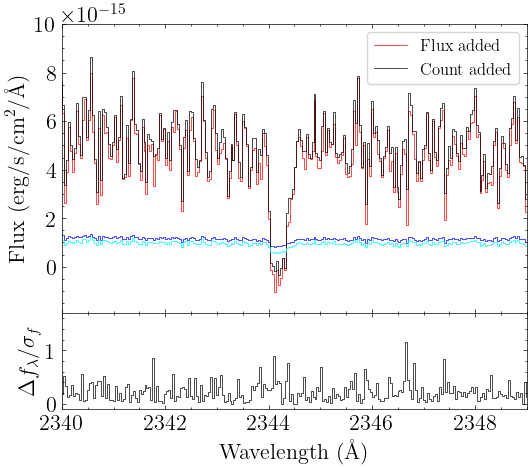

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(6,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(wav_stitch, flux_stitch_v1, where='mid', color='red', lw=.5, label='Flux added')
axes[0].step(wav_stitch, err_stitch_v1, where='mid', color='blue', lw=.5)

axes[0].step(wav_stitch, flux_stitch_v2, where='mid', color='black', lw=.5, label='Count added')
axes[0].step(wav_stitch, err_stitch_v2, where='mid', color='cyan', lw=.5)

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

axes[0].legend(loc='upper right')
axes[0].set_xlim(2300,2400)
axes[0].set_ylim(-1.9e-15, 1e-14)

axes[1].step(wav_stitch, (flux_stitch_v2-flux_stitch_v1)/np.sqrt(err_stitch_v1**2+err_stitch_v2**2), 
             lw=.5, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')

plt.subplots_adjust(wspace=0.2, hspace=0)

axes[1].set_ylim(-0.1, 1.7)
axes[1].set_xlim(2340,2349)


# Error estimation in count co-add

(-2e-15, 1e-14)

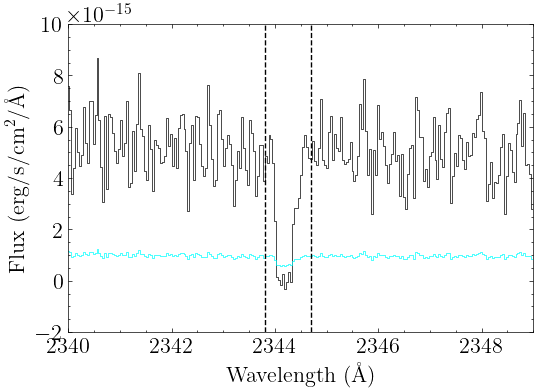

In [60]:
fig, ax = plt.subplots(1, figsize=(6,4))

ax.step(wav_stitch, flux_stitch_v2, where='mid', color='black', lw=.5)
ax.step(wav_stitch, err_stitch_v2, where='mid', color='cyan', lw=.5)

ax.axvline(2343.8, linestyle='--')
ax.axvline(2344.7, linestyle='--')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

ax.set_xlim(2340,2349)
ax.set_ylim(-2e-15, 1e-14)

In [61]:
cont_idx = ((wav_stitch>2342)&(wav_stitch<2343.8))|((wav_stitch>2344.7)&(wav_stitch<2349))

In [62]:
np.nanstd(flux_stitch_v2[cont_idx]), np.nanmean(err_stitch_v2[cont_idx])

(1.083218184089239e-15, 9.744977059211686e-16)

# Comparison with Zhijie's reduction (count co-add)

In [63]:
fits_zq = fits.open(rootdir+'J011035/J0110_ext4_all.fits')
wave_zq = fits_zq[1].data['wave']
flux_zq = fits_zq[1].data['flux']
err_zq = fits_zq[1].data['error']

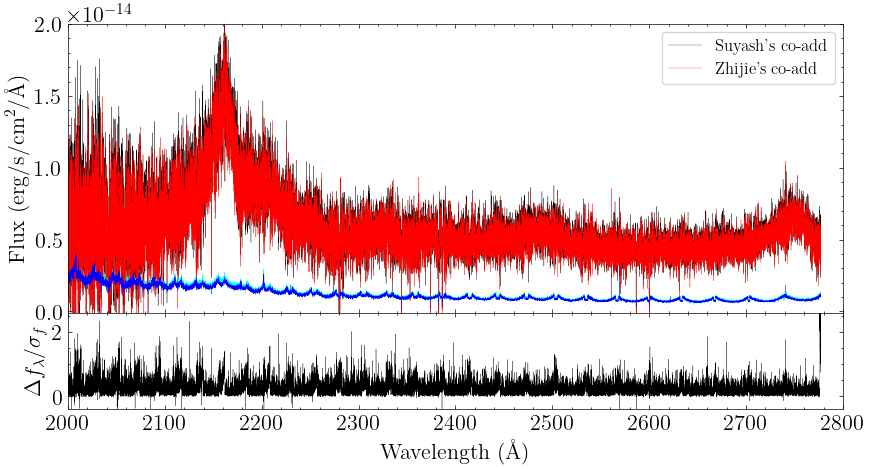

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(10,5.), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(wav_stitch, flux_stitch_v2, where='mid', color='black', lw=.2, label="Suyash's co-add")
axes[0].step(wav_stitch, err_stitch_v2, where='mid', color='cyan', lw=.2)

axes[0].step(wave_zq, flux_zq, where='mid', color='red', lw=.2, label="Zhijie's co-add")
axes[0].step(wave_zq, err_zq, where='mid', color='blue', lw=.2)

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

axes[0].legend(loc='upper right')
axes[0].set_xlim(2000,2800)
axes[0].set_ylim(-1e-16,2e-14)


axes[1].step(wav_stitch, (flux_stitch_v2-flux_stitch_v1)/np.sqrt(err_stitch_v1**2+err_stitch_v2**2), 
             lw=.2, color='black')

axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-0.4, 2.6)
plt.subplots_adjust(wspace=0.2, hspace=0)

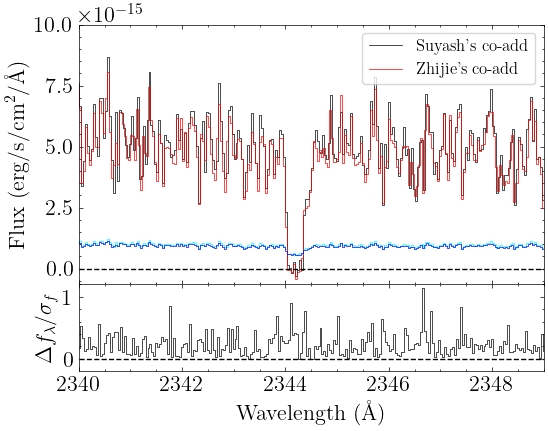

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(6,4.5), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

axes[0].step(wav_stitch, flux_stitch_v2, where='mid', color='black', lw=.5, label="Suyash's co-add")
axes[0].step(wav_stitch, err_stitch_v2, where='mid', color='cyan', lw=.5)

axes[0].step(wave_zq, flux_zq, where='mid', color='red', lw=.5, label="Zhijie's co-add")
axes[0].step(wave_zq, err_zq, where='mid', color='blue', lw=.5)

axes[0].set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

axes[0].legend(loc='upper right')
axes[0].set_xlim(2000,2800)
axes[0].set_ylim(-6.5e-16,1e-14)
axes[0].axhline(0, linestyle='--')
axes[0].set_xlim(2340,2349)

axes[1].step(wav_stitch, (flux_stitch_v2-flux_stitch_v1)/np.sqrt(err_stitch_v1**2+err_stitch_v2**2), 
             lw=.5, color='black')

axes[1].axhline(0, linestyle='--')
axes[1].set_ylabel(r'$\Delta f_\lambda / \sigma_f$')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylim(-0.2, 1.2)
plt.subplots_adjust(wspace=0.2, hspace=0)

# Effect of extrsize on S/N

In [3]:
f = fits.open(rootdir+'J011035/unstitched_es=4/of8g05010_x1d.fits')

In [4]:
f.info()

Filename: /Users/thepoetoftwilight/Documents/CUBS/Data/CONTACT/STIS/J011035/unstitched_es=4/of8g05010_x1d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     278   ()      
  1  SCI           1 BinTableHDU    158   30R x 19C   [1I, 1I, 1024D, 1024E, 1024E, 1024E, 1024E, 1024E, 1024E, 1024I, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1024E, 1E]   


In [5]:
f[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                38946 / width of table in bytes                        
NAXIS2  =                   30 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                   19 / number of fields in each row                   
TTYPE1  = 'SPORDER '           / label for field   1                            
TFORM1  = '1I      '           / data format of field: 2-byte INTEGER           
TTYPE2  = 'NELEM   '           / label for field   2                            
TFORM2  = '1I      '           / data format of field: 2-byte INTEGER           
TTYPE3  = 'WAVELENGTH'      

In [15]:
wav_grid = f[1].data['wavelength']
gross_grid = f[1].data['gross']
bg_grid = f[1].data['background']
net_grid = f[1].data['net']
flux_grid = f[1].data['flux']
err_grid = f[1].data['error']
dq_grid = f[1].data['dq']

(2000.0, 2020.0)

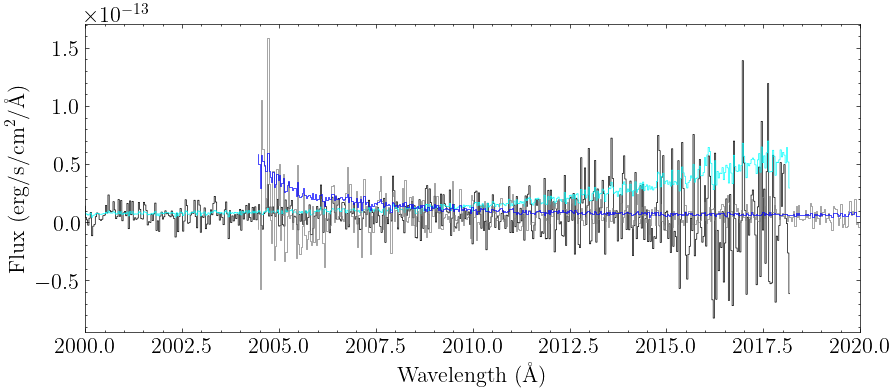

In [27]:
fig, ax = plt.subplots(1, figsize=(10,4))

ax.step(wav_grid[-1,:], flux_grid[-1,:], where='mid', color='black', lw=.5)
ax.step(wav_grid[-1,:], err_grid[-1,:], where='mid', color='cyan', lw=.5)

ax.step(wav_grid[-2,:], flux_grid[-2,:], where='mid', color='grey', lw=.5)
ax.step(wav_grid[-2,:], err_grid[-2,:], where='mid', color='blue', lw=.5)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (erg/s/cm${}^2$/Å)')

ax.set_xlim(2000, 2020)

(2000.0, 2020.0)

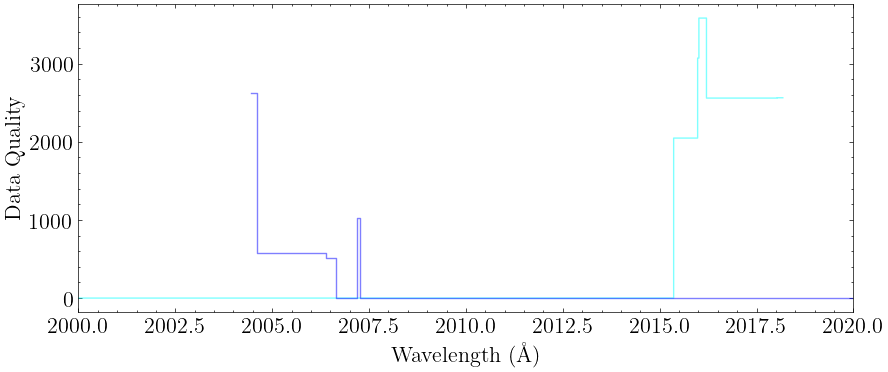

In [31]:
fig, ax = plt.subplots(1, figsize=(10,4))

ax.step(wav_grid[-1,:], dq_grid[-1,:], alpha=.5, color='cyan', where='mid')

ax.step(wav_grid[-2,:], dq_grid[-2,:], alpha=.5, color='blue', where='mid')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Data Quality')
           
ax.set_xlim(2000, 2020)

(2000.0, 2020.0)

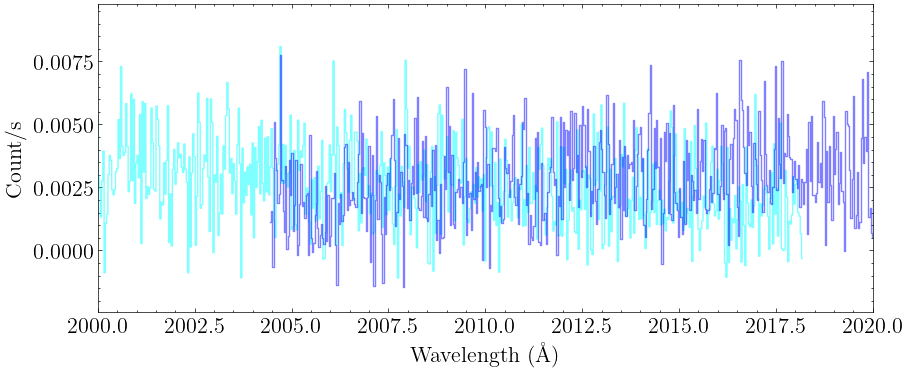

In [33]:
fig, ax = plt.subplots(1, figsize=(10,4))

ax.step(wav_grid[-1,:], gross_grid[-1,:], alpha=.5, color='cyan', where='mid')

ax.step(wav_grid[-2,:], gross_grid[-2,:], alpha=.5, color='blue', where='mid')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Count/s')
           
ax.set_xlim(2000, 2020)